In [1]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot  as plt
import anndata as ad

In [2]:
adata = ad.read_h5ad("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/01_extGBmap/immune_cells_extended_gbmap_hgnc.h5ad")

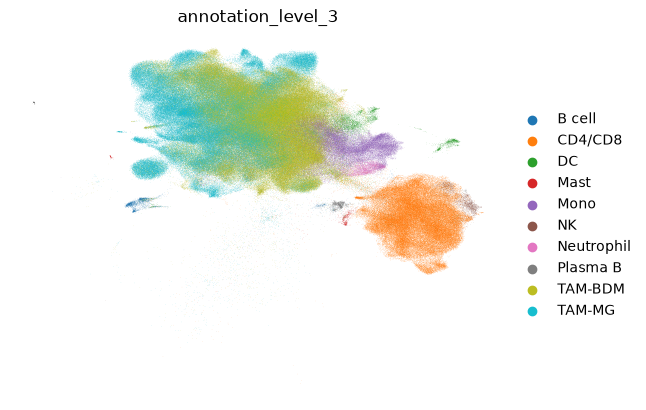

<Figure size 640x480 with 0 Axes>

In [5]:
sc.pl.umap(adata, color = ['annotation_level_3'], frameon=False)

plt.savefig("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/01_NMF_all_immune_cells/1_2_umap_annotation_level_3.pdf", dpi=300, bbox_inches="tight")

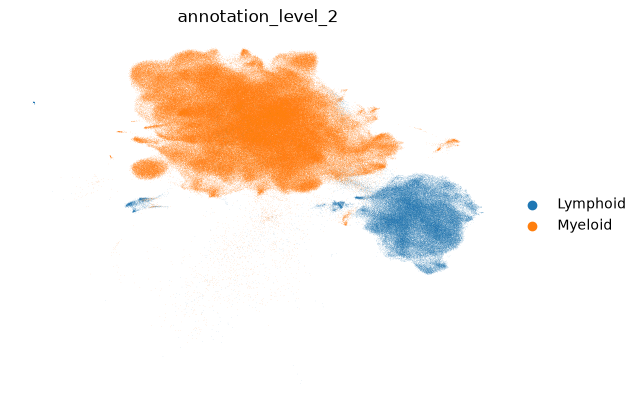

<Figure size 640x480 with 0 Axes>

In [6]:
sc.pl.umap(adata, color = ['annotation_level_2'], frameon=False)

plt.savefig("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/01_NMF_all_immune_cells/1_1_umap_annotation_level_2.pdf", dpi=300, bbox_inches="tight")

### barplot

In [7]:
BASE = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune"

OUT_DIR = f"{BASE}/results/01_all_immune_cells"


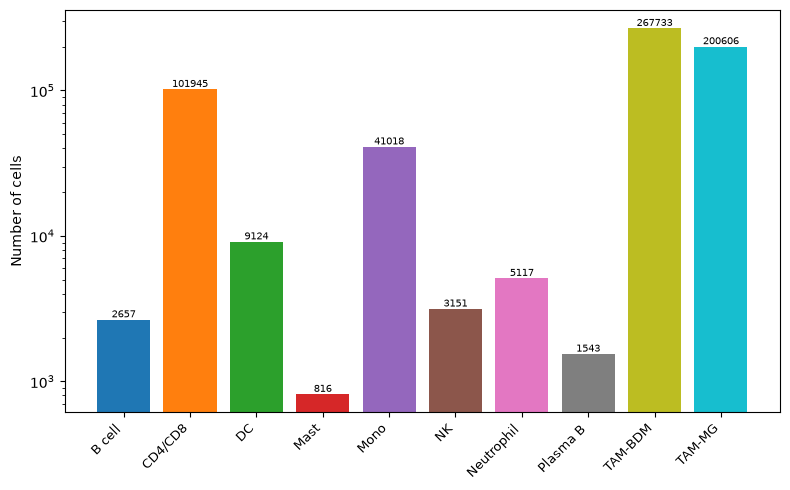

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import os

orig_col = "annotation_level_3"
orig_counts = adata.obs["annotation_level_3"].value_counts()

if f"{orig_col}_colors" in adata.uns:
    categories = adata.obs[orig_col].cat.categories.tolist()
    color_map = dict(zip(categories, adata.uns[f"{orig_col}_colors"]))
    orig_counts = orig_counts.reindex(categories)
    bar_colors = [color_map[ct] for ct in orig_counts.index]
else:
    bar_colors = "#808080"

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(orig_counts.index, orig_counts.values, color=bar_colors)
bars = ax.bar(orig_counts.index, orig_counts.values, color=bar_colors)
ax.set_yscale("log")
for bar, val in zip(bars, orig_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), str(val),
            ha="center", va="bottom", fontsize=7)
ax.set_ylabel("Number of cells", fontsize=10)
ax.set_xlabel("")
ax.set_xticks(range(len(orig_counts)))
ax.set_xticklabels(orig_counts.index, rotation=45, ha="right", fontsize=9)
plt.tight_layout()

plt.savefig(os.path.join(OUT_DIR,"1_3_barplot_level_3.pdf"), dpi=300)
plt.show()
plt.close()